<a href="https://colab.research.google.com/github/Aashna890/23102A0042-R_programming-Labs/blob/main/23102A0042_R_programming_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:

#############################
# TASK 1
# Import and Inspect Dataset
#############################
file_name <- "PRSA_Data_Aotizhongxin_20130301-20170228.csv"
air_data <- tryCatch({
  read.csv(file_name,
           header = TRUE,
           stringsAsFactors = FALSE)
}, error = function(e){
  cat("====================================\n")
  cat("ERROR OCCURRED\n")
  cat("====================================\n")
  if(!file.exists(file_name)){
    cat("File not found.\n")
  }else{
    cat("Unable to open dataset.\n")
    cat(conditionMessage(e), "\n")
  }
  return(NULL)
})
if(!is.null(air_data)){
cat("\n")
cat("====================================\n")
cat("TASK 1 OUTPUT\n")
cat("====================================\n")

cat("\nFirst Six Records\n")
print(head(air_data))

cat("\nDataset Structure\n")
str(air_data)

# Dimensions
cat("\nRows :", nrow(air_data), "\n")
cat("Columns :", ncol(air_data), "\n")

# Missing values present?

cat("\nContains Missing Values : ")

if(any(is.na(air_data))){
  cat("YES\n")
}else{
  cat("NO\n")
}

# Total Missing Values

cat("Total Missing Values :", sum(is.na(air_data)), "\n")

}


selected_variables <- c("PM2.5",
                        "PM10",
                        "SO2",
                        "NO2",
                        "TEMP",
                        "WSPM",
                        "wd")

numeric_variables <- c("PM2.5",
                       "PM10",
                       "SO2",
                       "NO2",
                       "TEMP",
                       "WSPM")


missing_before <- sapply(
  air_data[selected_variables],
  function(x) sum(is.na(x))
)

####################################################
# TASK 2
# NA, NULL and NaN
####################################################

cat("\n")
cat("====================================\n")
cat("TASK 2 OUTPUT\n")
cat("====================================\n")

temperature <- c(28,30,NA,32)

missing_object <- NULL

undefined_value <- 0/0

cat("\nTemperature Vector\n")
print(temperature)

cat("\nNULL Object\n")
print(missing_object)

cat("\nNaN Value\n")
print(undefined_value)

cat("\nis.na()\n")
print(is.na(temperature))

cat("\nis.null()\n")
print(is.null(missing_object))

cat("\nis.nan()\n")
print(is.nan(undefined_value))

####################################################
# TASK 3
# Missing Summary Function
####################################################

missing_summary <- function(data, variables){

  summary_table <- data.frame()

  for(variable in variables){

    total_records <- nrow(data)

    missing_values <- sum(is.na(data[[variable]]))

    missing_percentage <-
      round((missing_values/total_records)*100,2)

    temp <- data.frame(

      Variable = variable,

      Total_Records = total_records,

      Missing_Values = missing_values,

      Missing_Percentage = missing_percentage

    )

    summary_table <- rbind(summary_table,temp)

    if(missing_percentage > 20){

      warning(
        paste(variable,
              "contains more than 20% missing values.")
      )

    }

  }

  return(summary_table)

}

cat("\n")
cat("====================================\n")
cat("TASK 3 OUTPUT\n")
cat("====================================\n")

summary_table <-
  missing_summary(
    air_data,
    selected_variables
  )

print(summary_table)

####################################################
# TASK 4
# Pollution Ratio
####################################################

cat("\n")
cat("====================================\n")
cat("TASK 4 OUTPUT\n")
cat("====================================\n")

# Create new variable

air_data$pollution_ratio <-
  air_data$PM2.5 /
  air_data$PM10

# Count invalid values

na_count <-
  sum(is.na(air_data$pollution_ratio))

nan_count <-
  sum(is.nan(air_data$pollution_ratio))

inf_count <-
  sum(is.infinite(air_data$pollution_ratio))

cat("\nBefore Cleaning\n")

cat("NA :",na_count,"\n")

cat("NaN :",nan_count,"\n")

cat("Infinite :",inf_count,"\n")

# Replace NaN and Infinite with NA

air_data$pollution_ratio[
  is.nan(air_data$pollution_ratio)
] <- NA

air_data$pollution_ratio[
  is.infinite(air_data$pollution_ratio)
] <- NA

cat("\nAfter Cleaning\n")

cat(
"NA :",
sum(is.na(air_data$pollution_ratio)),
"\n"
)

cat(
"NaN :",
sum(is.nan(air_data$pollution_ratio)),
"\n"
)

cat(
"Infinite :",
sum(is.infinite(air_data$pollution_ratio)),
"\n"
)



TASK 1 OUTPUT

First Six Records
  No year month day hour PM2.5 PM10 SO2 NO2  CO O3 TEMP   PRES  DEWP RAIN  wd
1  1 2013     3   1    0     4    4   4   7 300 77 -0.7 1023.0 -18.8    0 NNW
2  2 2013     3   1    1     8    8   4   7 300 77 -1.1 1023.2 -18.2    0   N
3  3 2013     3   1    2     7    7   5  10 300 73 -1.1 1023.5 -18.2    0 NNW
4  4 2013     3   1    3     6    6  11  11 300 72 -1.4 1024.5 -19.4    0  NW
5  5 2013     3   1    4     3    3  12  12 300 72 -2.0 1025.2 -19.5    0   N
6  6 2013     3   1    5     5    5  18  18 400 66 -2.2 1025.6 -19.6    0   N
  WSPM      station
1  4.4 Aotizhongxin
2  4.7 Aotizhongxin
3  5.6 Aotizhongxin
4  3.1 Aotizhongxin
5  2.0 Aotizhongxin
6  3.7 Aotizhongxin

Dataset Structure
'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   : int  0 1 2 

In [41]:
####################################################
# TASK 5
# Replace Missing Numerical Values Using Median
####################################################

cat("\n")
cat("====================================\n")
cat("TASK 5 OUTPUT\n")
cat("====================================\n")

for(variable in numeric_variables){

  if(!(variable %in% names(air_data))){
    cat(variable,"does not exist.\n")
    next
  }

  missing_before_var <- sum(is.na(air_data[[variable]]))

  median_value <- median(air_data[[variable]], na.rm = TRUE)

  air_data[[variable]][is.na(air_data[[variable]])] <- median_value

  missing_after_var <- sum(is.na(air_data[[variable]]))

  cat("------------------------------------\n")
  cat("Variable :",variable,"\n")
  cat("Missing Before :",missing_before_var,"\n")
  cat("Median Used :",median_value,"\n")
  cat("Missing After :",missing_after_var,"\n\n")

}

####################################################
# TASK 6
# Replace Missing wd using Mode
####################################################

cat("\n")
cat("====================================\n")
cat("TASK 6 OUTPUT\n")
cat("====================================\n")

calculate_mode <- function(x){

  x <- x[!is.na(x)]

  if(length(x)==0){
    return(NA)
  }

  names(sort(table(x), decreasing=TRUE))[1]

}

mode_value <- calculate_mode(air_data$wd)

wd_before <- sum(is.na(air_data$wd))

air_data$wd[is.na(air_data$wd)] <- mode_value

wd_after <- sum(is.na(air_data$wd))

cat("Mode of wd :",mode_value,"\n")
cat("Missing Before :",wd_before,"\n")
cat("Missing After :",wd_after,"\n")

####################################################
# TASK 7
# Error Handling Function
####################################################

cat("\n")
cat("====================================\n")
cat("TASK 7 OUTPUT\n")
cat("====================================\n")

clean_variable <- function(data, variable){

  tryCatch({

    if(!(variable %in% names(data))){
      stop("Variable does not exist.")
    }

    if(!is.numeric(data[[variable]])){
      stop("Variable is not numeric.")
    }

    if(all(is.na(data[[variable]]))){
      stop("Variable contains only missing values.")
    }

    med <- median(data[[variable]], na.rm=TRUE)

    if(is.na(med)){
      stop("Median cannot be calculated.")
    }

    data[[variable]][is.na(data[[variable]])] <- med

    cat(variable,"cleaned successfully.\n")

    return(data[[variable]])

  },

  error=function(e){

    cat("Error :",conditionMessage(e),"\n")

    return(NULL)

  })

}

# Demonstration

air_data$PM2.5 <- clean_variable(air_data,"PM2.5")

clean_variable(air_data,"wd")

clean_variable(air_data,"XYZ")

####################################################
# TASK 8
# Comparison Table
####################################################

cat("\n")
cat("====================================\n")
cat("TASK 8 OUTPUT\n")
cat("====================================\n")

# Missing values AFTER cleaning

missing_after <- sapply(

  air_data[selected_variables],

  function(x){

    sum(is.na(x))

  }

)

# Comparison table

comparison_table <- data.frame(

  Variable = selected_variables,

  Missing_Before = as.vector(missing_before),

  Missing_After = as.vector(missing_after),

  Values_Replaced = as.vector(missing_before - missing_after),

  stringsAsFactors = FALSE

)

print(comparison_table)
####################################################
# Interpretation
####################################################

cat("\n")
cat("INTERPRETATION\n")
cat("--------------\n")

if(all(comparison_table$Missing_After==0)){

cat("All selected variables were cleaned successfully.\n")
cat("Missing numerical values were replaced using the median,\n")
cat("while missing values in wd were replaced using the mode.\n")
cat("The dataset is now suitable for further analysis.\n")

}else{

cat("Some variables still contain missing values.\n")

}


TASK 5 OUTPUT
------------------------------------
Variable : PM2.5 
Missing Before : 0 
Median Used : 58 
Missing After : 0 

------------------------------------
Variable : PM10 
Missing Before : 0 
Median Used : 87 
Missing After : 0 

------------------------------------
Variable : SO2 
Missing Before : 0 
Median Used : 9 
Missing After : 0 

------------------------------------
Variable : NO2 
Missing Before : 0 
Median Used : 53 
Missing After : 0 

------------------------------------
Variable : TEMP 
Missing Before : 0 
Median Used : 14.5 
Missing After : 0 

------------------------------------
Variable : WSPM 
Missing Before : 0 
Median Used : 1.4 
Missing After : 0 


TASK 6 OUTPUT
Mode of wd : NE 
Missing Before : 0 
Missing After : 0 

TASK 7 OUTPUT
PM2.5 cleaned successfully.
Error : Variable is not numeric. 


NULL

Error : Variable does not exist. 


NULL


TASK 8 OUTPUT
  Variable Missing_Before Missing_After Values_Replaced
1    PM2.5            925             0             925
2     PM10            718             0             718
3      SO2            935             0             935
4      NO2           1023             0            1023
5     TEMP             20             0              20
6     WSPM             14             0              14
7       wd             81             0              81

INTERPRETATION
--------------
All selected variables were cleaned successfully.
Missing numerical values were replaced using the median,
while missing values in wd were replaced using the mode.
The dataset is now suitable for further analysis.



TASK 9 OUTPUT
Bar chart generated successfully.

TASK 10 OUTPUT
Dataset exported successfully.
File Name : cleaned_air_quality_data.csv


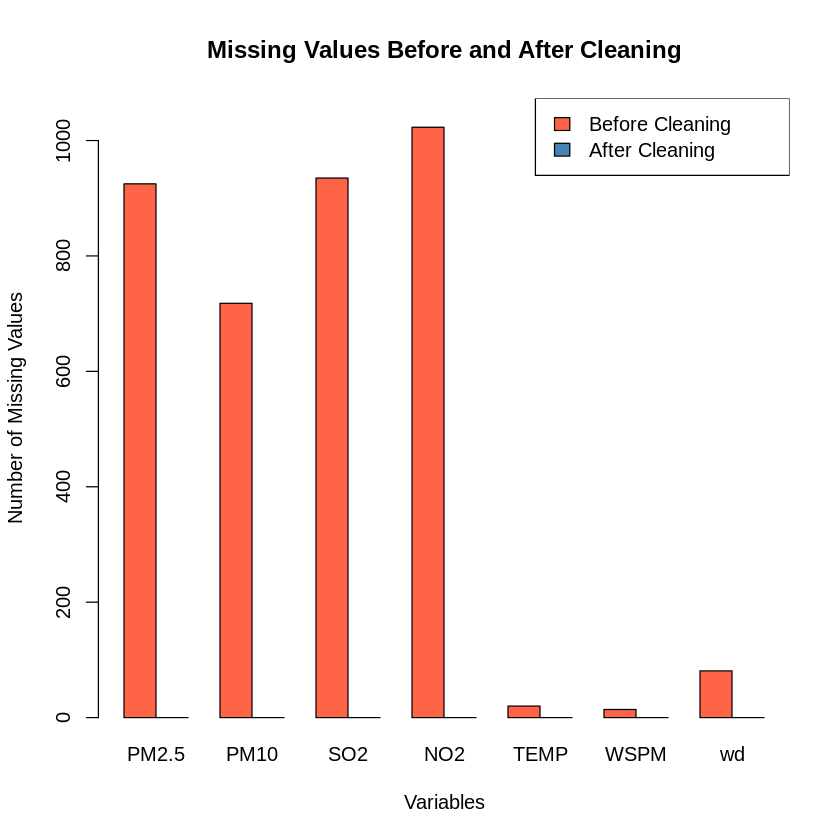

In [40]:
####################################################
# TASK 9
# Missing Value Visualization
####################################################

cat("\n")
cat("====================================\n")
cat("TASK 9 OUTPUT\n")
cat("====================================\n")

missing_matrix <- rbind(
  Before = as.numeric(missing_before),
  After = as.numeric(missing_after)
)

colnames(missing_matrix) <- selected_variables

barplot(
  missing_matrix,
  beside = TRUE,
  col = c("tomato", "steelblue"),
  main = "Missing Values Before and After Cleaning",
  xlab = "Variables",
  ylab = "Number of Missing Values",
  ylim = c(0, max(missing_matrix) + 50)
)

legend(
  "topright",
  legend = c("Before Cleaning", "After Cleaning"),
  fill = c("tomato", "steelblue")
)

cat("Bar chart generated successfully.\n")

####################################################
# TASK 10
# Export Cleaned Dataset
####################################################

cat("\n")
cat("====================================\n")
cat("TASK 10 OUTPUT\n")
cat("====================================\n")

write.csv(
  air_data,
  "cleaned_air_quality_data.csv",
  row.names = FALSE
)

cat("Dataset exported successfully.\n")
cat("File Name : cleaned_air_quality_data.csv\n")

